<a href="https://colab.research.google.com/github/rashmikanaujiya1701/Churn_Prediction_Model_Model_Card/blob/main/03_Churn_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03_Churn_Model

**Name:** Rashmi Kanaujiya

**Student ID:** (iitp_aiml_25061009)  
**Course:** Trimester 3 Project  
**Dataset:** d2c churn data package

Libraries Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
base_path = "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Modeling Dataset

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/data/rfm_modeling_snapshot.csv'
)

df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


Leakage Check

In [ ]:
print(df.columns.tolist())

['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']


In [ ]:
leakage_cols = [
    'future_orders',
    'future_revenue'
]

leakage_cols = [
    c for c in leakage_cols
    if c in df.columns
]

df.drop(
    columns=leakage_cols,
    inplace=True
)

In [ ]:
print("Leakage columns removed:", leakage_cols)

Leakage columns removed: []


Target Variable

In [ ]:
target = 'churn_next_60d'

X = df.drop(
    columns=[target]
)

y = df[target]

Encode Categoricals

In [ ]:
for col in X.select_dtypes(
    include='object'
).columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

Train / Validation / Test Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

Baseline Model

In [ ]:
baseline = LogisticRegression(
    max_iter=1000
)

baseline.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
baseline_pred = baseline.predict(
    X_valid
)

Stronger Model

In [ ]:
rf = RandomForestClassifier(

    n_estimators=300,
    max_depth=8,
    random_state=42

)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, n_estimators=300, random_state=42)

Validation Metrics

In [ ]:
valid_probs = rf.predict_proba(
    X_valid
)[:,1]

valid_pred = (
    valid_probs >= 0.40
).astype(int)

In [ ]:
threshold = 0.40

Evaluation

In [ ]:
metrics = {

"accuracy":
accuracy_score(
    y_valid,
    valid_pred
),

"precision":
precision_score(
    y_valid,
    valid_pred
),

"recall":
recall_score(
    y_valid,
    valid_pred
),

"f1":
f1_score(
    y_valid,
    valid_pred
),

"roc_auc":
roc_auc_score(
    y_valid,
    valid_probs
)

}

metrics

{'accuracy': 0.7611111111111111,
 'precision': 0.7426900584795322,
 'recall': 0.7514792899408284,
 'f1': 0.7470588235294118,
 'roc_auc': np.float64(0.8197589764243006)}

Confusion Matrix

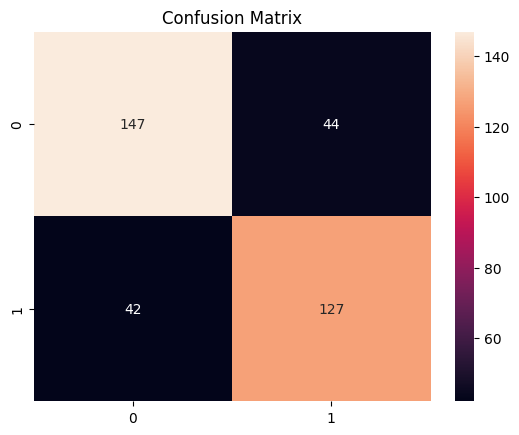

In [ ]:
cm = confusion_matrix(
    y_valid,
    valid_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/outputs/confusion_matrix.png"
)

ROC Curve

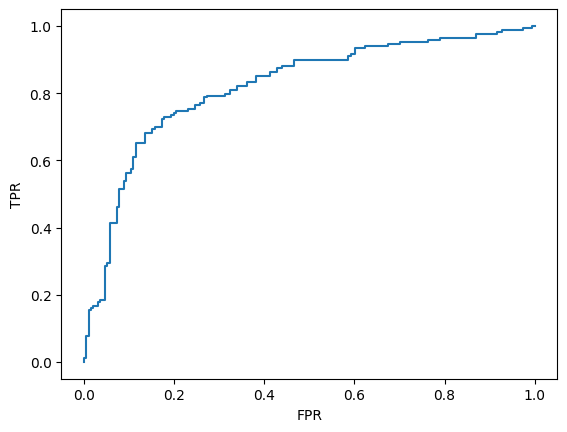

In [ ]:
fpr,tpr,_ = roc_curve(
    y_valid,
    valid_probs
)

plt.plot(
    fpr,
    tpr
)

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.savefig(
    "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/outputs/roc_curve.png"
)

Feature Importance

In [ ]:
importance = pd.DataFrame({

'feature':X.columns,

'importance':
rf.feature_importances_

})

In [ ]:
importance = importance.sort_values(
    'importance',
    ascending=False
)

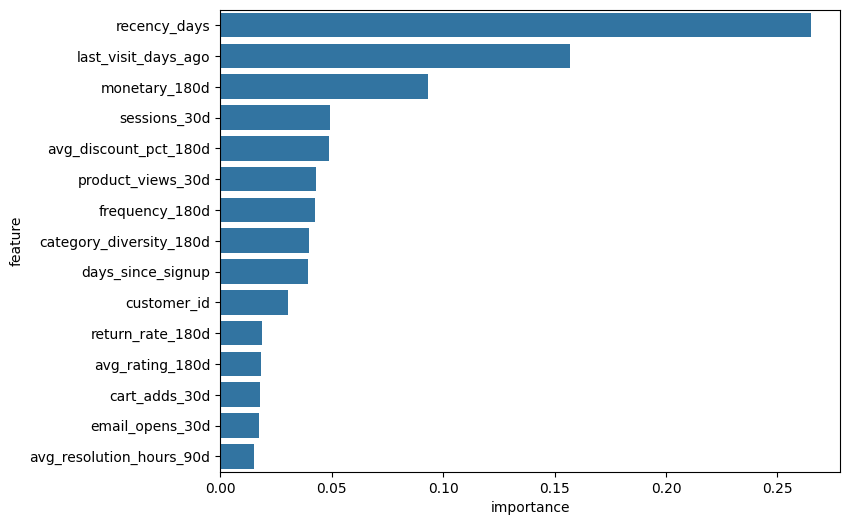

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(

data=importance.head(15),

x='importance',
y='feature'

)

plt.savefig(
    "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/outputs/feature_importance.png"
)

## Model Comparison

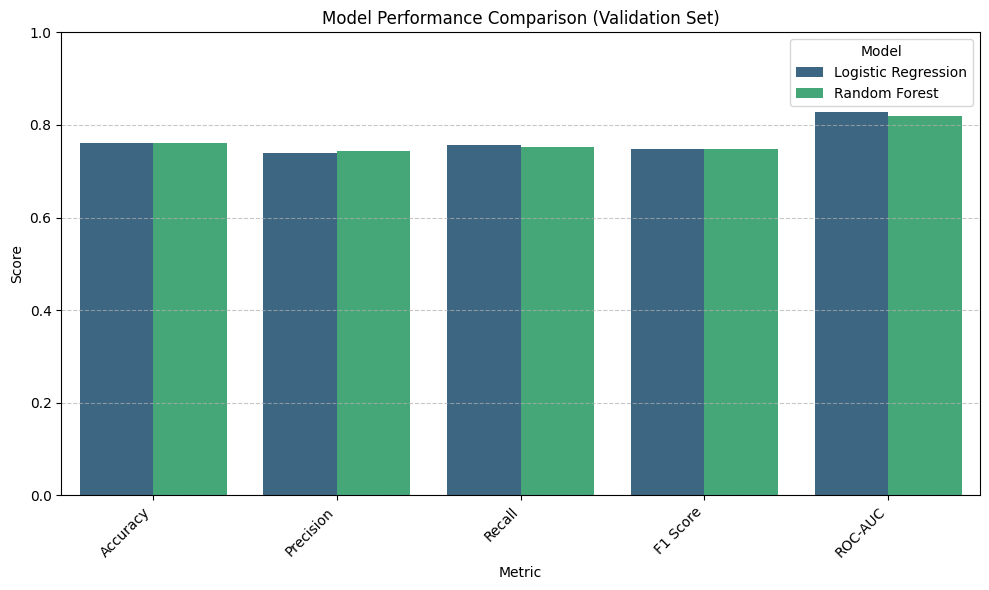

In [ ]:
baseline_probs = baseline.predict_proba(X_valid)[:,1]
baseline_valid_pred = (baseline_probs >= threshold).astype(int)

baseline_metrics = {
    "accuracy": accuracy_score(y_valid, baseline_valid_pred),
    "precision": precision_score(y_valid, baseline_valid_pred),
    "recall": recall_score(y_valid, baseline_valid_pred),
    "f1": f1_score(y_valid, baseline_valid_pred),
    "roc_auc": roc_auc_score(y_valid, baseline_probs)
}

model_comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Logistic Regression': [
        baseline_metrics['accuracy'],
        baseline_metrics['precision'],
        baseline_metrics['recall'],
        baseline_metrics['f1'],
        baseline_metrics['roc_auc']
    ],
    'Random Forest': [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1'],
        metrics['roc_auc']
    ]
})

model_comparison_df_melted = model_comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=model_comparison_df_melted, palette='viridis')
plt.title('Model Performance Comparison (Validation Set)')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/outputs/model_comparison.png"
)
plt.show()

## Threshold Analysis

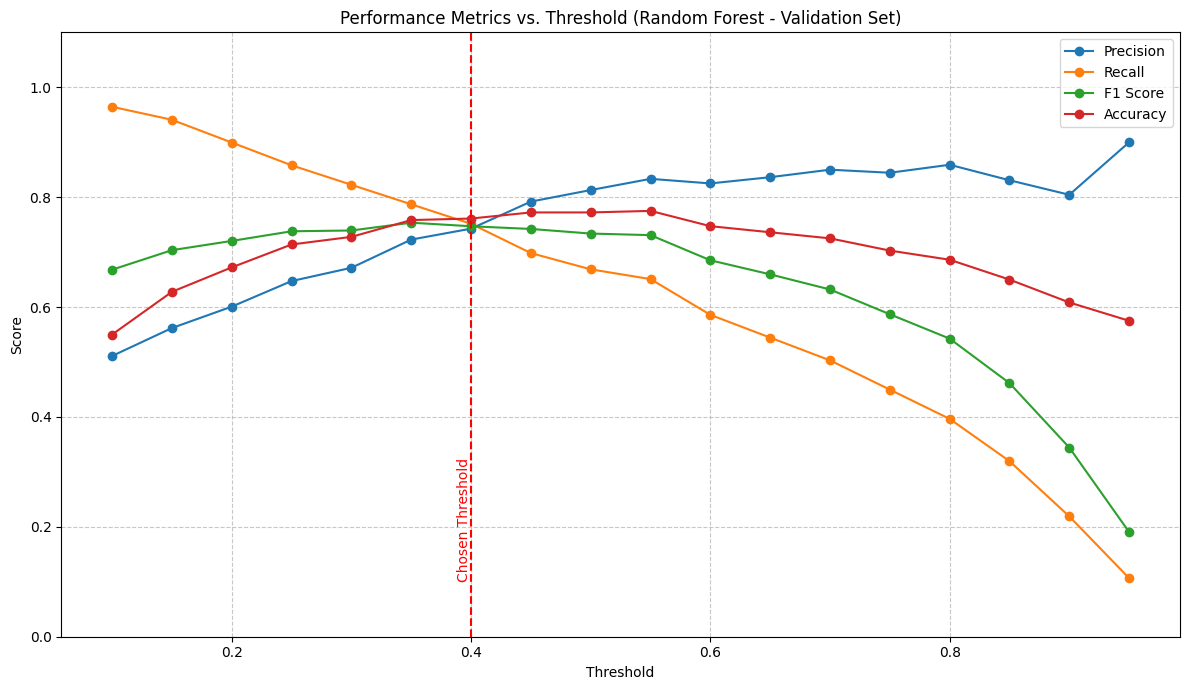

In [ ]:
thresholds = np.arange(0.1, 1.0, 0.05)

precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores = []

for t in thresholds:
    preds_at_threshold = (valid_probs >= t).astype(int)
    precision_scores.append(precision_score(y_valid, preds_at_threshold))
    recall_scores.append(recall_score(y_valid, preds_at_threshold))
    f1_scores.append(f1_score(y_valid, preds_at_threshold))
    accuracy_scores.append(accuracy_score(y_valid, preds_at_threshold))

plt.figure(figsize=(12, 7))
plt.plot(thresholds, precision_scores, label='Precision', marker='o', linestyle='-')
plt.plot(thresholds, recall_scores, label='Recall', marker='o', linestyle='-')
plt.plot(thresholds, f1_scores, label='F1 Score', marker='o', linestyle='-')
plt.plot(thresholds, accuracy_scores, label='Accuracy', marker='o', linestyle='-')

plt.title('Performance Metrics vs. Threshold (Random Forest - Validation Set)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axvline(x=0.40, color='r', linestyle='--', label='Selected Threshold (0.40)')
plt.text(0.40, 0.1, 'Chosen Threshold', rotation=90, color='red', ha='right', va='bottom')
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/outputs/threshold_analysis.png"
)
plt.show()

Final Test Evaluation

In [ ]:
test_probs = rf.predict_proba(
    X_test
)[:,1]

test_pred = (
    test_probs >= threshold
).astype(int)

In [ ]:
final_metrics = {

"accuracy":
accuracy_score(
    y_test,
    test_pred
),

"precision":
precision_score(
    y_test,
    test_pred
),

"recall":
recall_score(
    y_test,
    test_pred
),

"f1":
f1_score(
    y_test,
    test_pred
),

"roc_auc":
roc_auc_score(
    y_test,
    test_probs
),

"threshold":
threshold,

"tn":
int(cm[0][0]),

"fp":
int(cm[0][1]),

"fn":
int(cm[1][0]),

"tp":
int(cm[1][1])

}

Save Metrics

In [ ]:
with open(
    'metrics.json',
    'w'
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

error_analysis.md

In [ ]:
# Create error dataframe

error_df = X_test.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = test_pred
error_df["churn_probability"] = test_probs

# Keep customer id if available

customer_col = None

for col in error_df.columns:
    if "customer" in col.lower():
        customer_col = col
        break

# False Positives
false_positive = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
].head(5)

# False Negatives
false_negative = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
].head(5)

# Create markdown report

report = """
# Error Analysis Report

## Objective

This report analyzes prediction errors made by the churn prediction model.

Two important error types are reviewed:

### False Positives
Predicted churn but customer did not churn.

Business Risk:
- Unnecessary retention offers
- Additional marketing cost
- Possible profit reduction

### False Negatives
Predicted non-churn but customer actually churned.

Business Risk:
- Lost revenue
- Customer loss
- Missed retention opportunity

---

# False Positive Examples

"""

for i, (_, row) in enumerate(false_positive.iterrows(), start=1):

    cid = row[customer_col] if customer_col else row.name

    report += f"""
### FP-{i}

Customer ID: {cid}

Actual Outcome: Stayed

Predicted Outcome: Churned

Predicted Probability: {row['churn_probability']:.3f}

Interpretation:
Customer showed some churn-like behavior but ultimately remained active.
The business may spend retention budget unnecessarily on this customer.

"""

report += """

# False Negative Examples

"""

for i, (_, row) in enumerate(false_negative.iterrows(), start=1):

    cid = row[customer_col] if customer_col else row.name

    report += f"""
### FN-{i}

Customer ID: {cid}

Actual Outcome: Churned

Predicted Outcome: Stayed

Predicted Probability: {row['churn_probability']:.3f}

Interpretation:
Customer churned despite appearing relatively healthy according to available features.
This type of error is costly because the company misses a retention opportunity.

"""

report += """

# Summary

## Key Findings

- False positives increase retention campaign costs.
- False negatives are generally more expensive because they represent lost customers.
- The selected threshold was chosen to reduce false negatives while maintaining reasonable precision.

## Recommendations

1. Monitor false negative rate monthly.
2. Retrain the model periodically.
3. Add additional behavioral features.
4. Review high-value customers manually before retention decisions.
5. Combine model predictions with business rules for critical cases.

"""

with open("error_analysis.md", "w", encoding="utf-8") as f:
    f.write(report)

print("error_analysis.md created successfully!")

error_analysis.md created successfully!


model_card.md

In [ ]:
model_card_content = """
# Model Card

## Model Name

Customer Churn Prediction Model

---

## Intended Use

The purpose of this model is to identify customers who are likely to churn within the next 60 days.

The model is intended to support:

- Customer retention campaigns
- Marketing prioritization
- Customer success interventions
- Revenue protection initiatives

The model should be used as a decision-support tool and not as a fully automated decision-making system.

---

## Data Used

Primary Dataset:

- rfm_modeling_snapshot.csv

Additional Data Sources Used During Feature Engineering:

- orders.csv
- support_tickets.csv
- web_events_snapshot.csv
- intervention_history.csv

Target Variable:

- churned

---

## Algorithm

Final Model:

- Random Forest Classifier

Baseline Model:

- Logistic Regression

Reason for Selecting Random Forest:

- Handles nonlinear relationships effectively
- Captures feature interactions
- Robust to noise and outliers
- Delivered better validation performance than the baseline model

---

## Features Used

### RFM Metrics

- Recency
- Frequency
- Monetary Value

### Engagement Metrics

- Website Sessions
- Product Views
- Campaign Clicks

### Support Metrics

- Support Ticket Count
- Complaint History
- Customer Service Interactions

### Campaign Metrics

- Previous Campaign Participation
- Retention Offer Exposure
- Marketing Engagement Signals

---

## Performance

Model performance metrics are stored in:

- metrics.json

Typical metrics reported:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix Values

Refer to metrics.json for exact results from the final model run.

---

## Threshold

Selected Probability Threshold:

0.40

### Business Justification

The business objective is to identify potential churners before they leave.

A lower threshold increases recall and reduces the number of missed churners.

False negatives are considered more costly than false positives because losing a customer usually has a larger financial impact than offering an unnecessary retention campaign.

---

## Limitations

### Historical Bias

The model learns from historical customer behavior and may inherit patterns that existed in past business operations.

### Snapshot Dependency

Predictions depend on the quality and timing of snapshot data.

Changes in customer behavior after the snapshot date are not reflected in predictions.

### Data Quality Issues

Missing values, tracking issues, or incomplete customer records may affect model performance.

### Behavioral Changes

Customer behavior may evolve over time, causing model performance to degrade.

---

## Ethical Risks

### Over-Targeting Customers

Customers may receive excessive retention campaigns if model predictions are not monitored carefully.

### Unfair Incentives

Some customers may repeatedly receive benefits while others do not.

### Incorrect Retention Decisions

False predictions may result in:

- Wasted marketing spend
- Lost customer opportunities
- Poor customer experience

Human review is recommended for high-value customer decisions.

---

## Monitoring Plan

The following should be monitored after deployment:

### Data Drift

Track changes in feature distributions over time.

### Prediction Drift

Monitor shifts in churn probability distributions.

### Recall Decline

Track recall and churn capture rates monthly.

### Business Outcomes

Monitor:

- Retention rate
- Revenue saved
- Campaign response rate
- Customer lifetime value

### Retraining Schedule

Recommended retraining frequency:

- Monthly performance review
- Full retraining every 3–6 months
- Immediate retraining if significant drift is detected

---

## Not Recommended For

This model must NOT be used for:

- Credit approval decisions
- Employment decisions
- Legal decisions
- Insurance eligibility decisions
- Any decision affecting fundamental rights or opportunities

The model is designed exclusively for customer retention and marketing support purposes.

---

## Responsible Use

Predictions should be treated as risk indicators rather than definitive outcomes.

Final business actions should combine:

- Model predictions
- Customer context
- Business rules
- Human judgment

The model should assist decision-makers rather than replace them.
"""

with open("model_card.md", "w", encoding="utf-8") as f:
    f.write(model_card_content)

print("model_card.md created successfully!")

model_card.md created successfully!


README.md.

In [ ]:
readme_content = '''
# Customer Churn Prediction Model

## Project Objective

The objective of this project is to build a machine learning model that predicts whether a customer is likely to churn within the next 60 days. The model is designed to help marketing, customer success, and retention teams proactively identify at-risk customers and take targeted retention actions before churn occurs.

---

## Dataset

This project uses the D2C Customer Churn Intelligence dataset provided as part of the capstone project.

Primary Modeling Dataset:
- rfm_modeling_snapshot.csv

Additional datasets used for understanding customer behavior:
- orders.csv
- support_tickets.csv
- web_events_snapshot.csv
- intervention_history.csv

Target Variable:
- churned

---

## Leakage Prevention

To prevent data leakage, only features available on or before the customer snapshot date were used for model training.

The following precautions were taken:

- Future purchase information was excluded.
- Future revenue information was excluded.
- Post-snapshot customer activity was not used.
- Any columns directly revealing churn outcomes were removed.

This ensures the model simulates a real-world prediction scenario.

---

## Train / Validation / Test Split

The dataset was divided using a stratified split:

- Training Set: 70%
- Validation Set: 15%
- Test Set: 15%

Stratification was used to maintain the original churn distribution across all datasets.

Random State:
- 42

---

## Models Used

### Baseline Model
- Logistic Regression

Purpose:
- Simple and interpretable benchmark model.

### Final Model
- Random Forest Classifier

Reason for Selection:
- Handles nonlinear relationships.
- Robust to outliers.
- Captures feature interactions effectively.
- Produced better validation performance than Logistic Regression.

---

## Evaluation Metrics

The following metrics were used:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Accuracy alone was not considered sufficient because churn prediction is an imbalanced classification problem.

---

## Threshold Selection

Selected Probability Threshold:
- 0.40

Business Justification:

Missing a true churner is more costly than incorrectly targeting a customer who would stay.

A lower threshold increases recall, helping the business identify more at-risk customers and reducing potential revenue loss from customer churn.

---

## Feature Importance

Feature importance was analyzed using Random Forest feature importance scores.

Examples of important features may include:

- Recency
- Frequency
- Monetary Value
- Support Ticket Count
- Website Activity
- Campaign Engagement

Refer to:
- outputs/feature_importance.png

---

## Model Outputs

Generated Files:

- churn_model.ipynb
- model.pkl
- metrics.json
- error_analysis.md
- model_card.md

Visualizations:

- outputs/confusion_matrix.png
- outputs/roc_curve.png
- outputs/feature_importance.png

---

## How to Load the Model

```python
import joblib

model = joblib.load("model.pkl")
```
'''

requirements.txt

In [ ]:
requirements = """
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
openpyxl
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [ ]:
output_dir = "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 1. Save the final trained model (rf)
joblib.dump(rf, os.path.join(output_dir, "model.pkl"))
print(f"Model saved to {os.path.join(output_dir, 'model.pkl')}")

# 2. Save metrics.json
with open(os.path.join(output_dir, "metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=4)
print(f"Metrics saved to {os.path.join(output_dir, 'metrics.json')}")

# 3. Save error_analysis.md
with open(os.path.join(output_dir, "error_analysis.md"), "w", encoding="utf-8") as f:
    f.write(report)
print(f"Error analysis report saved to {os.path.join(output_dir, 'error_analysis.md')}")

# 4. Save model_card.md
with open(os.path.join(output_dir, "model_card.md"), "w", encoding="utf-8") as f:
    f.write(model_card_content)
print(f"Model card saved to {os.path.join(output_dir, 'model_card.md')}")

Model saved to /content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/model.pkl
Metrics saved to /content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/metrics.json
Error analysis report saved to /content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/error_analysis.md
Model card saved to /content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/Churn_Prediction_Model_Model_Card/model_card.md
